# Umurinzi Cyber: Explainable Machine Learning Intrusion Detection Model Training Notebook

**Student:** Edine Noella Mugisha  
**Project:** Umurinzi Cyber  
**Programme:** BSc. Software Engineering  
**Goal:** Train, evaluate, compare, explain, and save machine learning models for a five-class intrusion detection system.

This notebook follows the project proposal methodology. It uses the already prepared merged dataset:

```text
umurinzi_merged_800k.csv
```

The dataset was created from:

- **CICIDS2017:** 400,000 sampled records
- **UNSW-NB15:** 400,000 sampled records

The classification task is multiclass network intrusion detection with five classes:

| Numeric Label | Class |
|---:|---|
| 0 | NORMAL |
| 1 | DoS |
| 2 | Probe |
| 3 | Exploitation |
| 4 | Backdoor |

The notebook includes:

1. Dataset loading and validation  
2. Exploratory Data Analysis  
3. Data quality checks  
4. Feature engineering  
5. Information Gain feature selection  
6. Stratified train/test split  
7. Min-Max scaling  
8. SMOTE class balancing on training data only  
9. Logistic Regression baseline  
10. Random Forest with cross-validation and hyperparameter tuning  
11. XGBoost with cross-validation and hyperparameter tuning  
12. Model comparison  
13. Best model selection  
14. SHAP explainability  
15. Isolation Forest anomaly detection  
16. Final model artifact saving

## 1. Environment Setup

Run this notebook on your local PC using Python 3.11 or later.

If any package is missing, uncomment and run the installation cell below.

In [2]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import shap
import joblib

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

sns.set_context('notebook')

print('Environment ready.')

Environment ready.


## 2. Configuration

In [3]:
# ===================== USER CONFIGURATION =====================
DATASET_PATH = r"umurinzi_merged_800k.csv"
OUTPUT_DIR = Path("umurinzi_model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Stronger performance settings.
# If your PC is slow, reduce these values.
N_JOBS = -1
CV_FOLDS = 5

# Feature selection setting.
# Use None to keep all features after ranking.
TOP_K_FEATURES = None

# To make training faster during debugging, set this to a number like 100000.
# For final project training, keep it as None.
MAX_ROWS_FOR_DEBUG = None

print('Dataset path:', DATASET_PATH)
print('Output folder:', OUTPUT_DIR.resolve())

Dataset path: umurinzi_merged_800k.csv
Output folder: /Users/edine.mugisha/Documents/School/Capstone/Notebook/umurinzi_model_outputs


## 3. Dataset Loading

This section loads the already merged dataset. No raw CICIDS2017 or UNSW-NB15 files are needed in this notebook.

In [4]:
if not Path(DATASET_PATH).exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}\n"
        "Please update DATASET_PATH to the correct location of umurinzi_merged_800k.csv."
    )

load_start = time.time()
df = pd.read_csv(DATASET_PATH)
load_time = time.time() - load_start

if MAX_ROWS_FOR_DEBUG is not None:
    df = df.sample(n=min(MAX_ROWS_FOR_DEBUG, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Dataset loaded in {load_time:.2f} seconds")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())

Dataset loaded in 0.22 seconds
Rows: 199,754
Columns: 28


,dest_port,protocol,flow_duration,fwd_pkts,bwd_pkts,fwd_bytes,bwd_bytes,fwd_pkt_len_mean,bwd_pkt_len_mean,fwd_iat_mean,bwd_iat_mean,fwd_iat_std,bwd_iat_std,flow_bytes_per_sec,flow_pkts_per_sec,syn_flag_count,ack_flag_count,rst_flag_count,psh_flag_count,fwd_win,bwd_win,fwd_load,bwd_load,ct_srv_src,ct_dst_ltm,dataset_source,label,unified_label
0,52714.0,0,11.0,1,1,6,6,6.00,6.000000,0.00000,0.0,0.000000,0.000000,1.090909e+06,181818.181800,0,1,0,0,237,256,1.090909e+06,1.090909e+06,0,0,0,4,Backdoor
1,8080.0,0,1029450.0,3,3,0,18,0.00,6.000000,514487.00000,514315.5,1629.174024,1745.846643,1.748506e+01,5.828355,0,0,0,1,8192,0,1.748506e+01,1.748506e+01,0,0,0,4,Backdoor
2,8080.0,0,79794.0,4,3,207,134,51.75,44.666667,26598.00000,39227.0,45542.383440,54636.726770,4.273504e+03,87.725894,0,0,0,1,8192,237,4.273504e+03,4.273504e+03,0,0,0,4,Backdoor
3,8080.0,0,78863.0,4,3,206,134,51.50,44.666667,26287.66667,38694.5,44967.582290,53804.462090,4.311274e+03,88.761523,0,0,0,1,8192,237,4.311274e+03,4.311274e+03,0,0,0,4,Backdoor
4,52860.0,0,3.0,1,1,6,6,6.00,6.000000,0.00000,0.0,0.000000,0.000000,4.000000e+06,666666.666700,0,1,0,0,237,256,4.000000e+06,4.000000e+06,0,0,0,4,Backdoor


In [5]:
print('Column names:')
for i, col in enumerate(df.columns, start=1):
    print(f'{i:2d}. {col}')

print('\nData types:')
display(df.dtypes)

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f'\nMemory usage: {memory_mb:.2f} MB')

Column names:
 1. dest_port
 2. protocol
 3. flow_duration
 4. fwd_pkts
 5. bwd_pkts
 6. fwd_bytes
 7. bwd_bytes
 8. fwd_pkt_len_mean
 9. bwd_pkt_len_mean
10. fwd_iat_mean
11. bwd_iat_mean
12. fwd_iat_std
13. bwd_iat_std
14. flow_bytes_per_sec
15. flow_pkts_per_sec
16. syn_flag_count
17. ack_flag_count
18. rst_flag_count
19. psh_flag_count
20. fwd_win
21. bwd_win
22. fwd_load
23. bwd_load
24. ct_srv_src
25. ct_dst_ltm
26. dataset_source
27. label
28. unified_label

Data types:


dest_port             float64
protocol                int64
flow_duration         float64
fwd_pkts                int64
bwd_pkts                int64
fwd_bytes               int64
bwd_bytes               int64
fwd_pkt_len_mean      float64
bwd_pkt_len_mean      float64
fwd_iat_mean          float64
bwd_iat_mean          float64
fwd_iat_std           float64
bwd_iat_std           float64
flow_bytes_per_sec    float64
flow_pkts_per_sec     float64
syn_flag_count          int64
ack_flag_count          int64
rst_flag_count          int64
psh_flag_count          int64
fwd_win                 int64
bwd_win                 int64
fwd_load              float64
bwd_load              float64
ct_srv_src              int64
ct_dst_ltm              int64
dataset_source          int64
label                   int64
unified_label          object
dtype: object


Memory usage: 51.59 MB


## 4. Expected Schema Validation

The dataset must contain the expected 28 columns produced during the merging phase.

In [6]:
expected_columns = [
    'dest_port', 'protocol', 'flow_duration',
    'fwd_pkts', 'bwd_pkts', 'fwd_bytes', 'bwd_bytes',
    'fwd_pkt_len_mean', 'bwd_pkt_len_mean',
    'fwd_iat_mean', 'bwd_iat_mean', 'fwd_iat_std', 'bwd_iat_std',
    'flow_bytes_per_sec', 'flow_pkts_per_sec',
    'syn_flag_count', 'ack_flag_count', 'rst_flag_count', 'psh_flag_count',
    'fwd_win', 'bwd_win',
    'fwd_load', 'bwd_load',
    'ct_srv_src', 'ct_dst_ltm',
    'dataset_source',
    'label',
    'unified_label',
]

missing_cols = sorted(set(expected_columns) - set(df.columns))
extra_cols = sorted(set(df.columns) - set(expected_columns))

print('Missing expected columns:', missing_cols)
print('Extra columns:', extra_cols)

if missing_cols:
    raise ValueError('The dataset is missing required columns. Fix this before training.')

# Reorder columns for consistency.
df = df[expected_columns].copy()
print('Schema validation passed.')

Missing expected columns: []
Extra columns: []
Schema validation passed.


## 5. Exploratory Data Analysis

This section provides the descriptive analysis needed to understand the merged dataset before model training.

In [7]:
print('Dataset shape:', df.shape)
print('\nFirst rows:')
display(df.head())
print('\nLast rows:')
display(df.tail())

Dataset shape: (199754, 28)

First rows:


,dest_port,protocol,flow_duration,fwd_pkts,bwd_pkts,fwd_bytes,bwd_bytes,fwd_pkt_len_mean,bwd_pkt_len_mean,fwd_iat_mean,bwd_iat_mean,fwd_iat_std,bwd_iat_std,flow_bytes_per_sec,flow_pkts_per_sec,syn_flag_count,ack_flag_count,rst_flag_count,psh_flag_count,fwd_win,bwd_win,fwd_load,bwd_load,ct_srv_src,ct_dst_ltm,dataset_source,label,unified_label
0,52714.0,0,11.0,1,1,6,6,6.00,6.000000,0.00000,0.0,0.000000,0.000000,1.090909e+06,181818.181800,0,1,0,0,237,256,1.090909e+06,1.090909e+06,0,0,0,4,Backdoor
1,8080.0,0,1029450.0,3,3,0,18,0.00,6.000000,514487.00000,514315.5,1629.174024,1745.846643,1.748506e+01,5.828355,0,0,0,1,8192,0,1.748506e+01,1.748506e+01,0,0,0,4,Backdoor
2,8080.0,0,79794.0,4,3,207,134,51.75,44.666667,26598.00000,39227.0,45542.383440,54636.726770,4.273504e+03,87.725894,0,0,0,1,8192,237,4.273504e+03,4.273504e+03,0,0,0,4,Backdoor
3,8080.0,0,78863.0,4,3,206,134,51.50,44.666667,26287.66667,38694.5,44967.582290,53804.462090,4.311274e+03,88.761523,0,0,0,1,8192,237,4.311274e+03,4.311274e+03,0,0,0,4,Backdoor
4,52860.0,0,3.0,1,1,6,6,6.00,6.000000,0.00000,0.0,0.000000,0.000000,4.000000e+06,666666.666700,0,1,0,0,237,256,4.000000e+06,4.000000e+06,0,0,0,4,Backdoor



Last rows:


,dest_port,protocol,flow_duration,fwd_pkts,bwd_pkts,fwd_bytes,bwd_bytes,fwd_pkt_len_mean,bwd_pkt_len_mean,fwd_iat_mean,bwd_iat_mean,fwd_iat_std,bwd_iat_std,flow_bytes_per_sec,flow_pkts_per_sec,syn_flag_count,ack_flag_count,rst_flag_count,psh_flag_count,fwd_win,bwd_win,fwd_load,bwd_load,ct_srv_src,ct_dst_ltm,dataset_source,label,unified_label
199749,53.0,17,7.0,2,0,114,0,57.0,0.0,0.007000,0.000000,0.000000,0.000000,8.142857e+06,285714.285714,0,0,0,0,0,0,8.142857e+06,0.000000,17,17,1,2,Probe
199750,1900.0,6,1621991.0,20,10,15410,456,771.0,46.0,83.599000,172.423781,6559.110311,301.272156,9.279336e+03,18.495787,0,1,0,0,255,255,9.025943e+03,253.392273,2,2,1,2,Probe
199751,111.0,6,1064099.0,10,8,564,354,56.0,44.0,116.466444,144.968281,7931.435407,196.550047,7.687255e+02,16.915719,0,1,0,0,255,255,4.773992e+02,291.326294,1,1,1,2,Probe
199752,514.0,17,11.0,2,0,616,0,308.0,0.0,0.011000,0.000000,0.000000,0.000000,2.800000e+07,181818.181818,0,0,0,0,0,0,2.800000e+07,0.000000,6,1,1,2,Probe
199753,111.0,17,2.0,2,0,168,0,84.0,0.0,0.002000,0.000000,0.000000,0.000000,4.200000e+07,1000000.000000,0,0,0,0,0,0,4.200000e+07,0.000000,5,1,1,2,Probe


In [8]:
print('Unified class distribution:')
class_counts = df['unified_label'].value_counts()
display(class_counts.to_frame('count'))

print('\nClass percentage distribution:')
class_percentages = (df['unified_label'].value_counts(normalize=True) * 100).round(2)
display(class_percentages.to_frame('percentage'))

Unified class distribution:


,count
unified_label,
NORMAL,178030
DoS,13039
Probe,6642
Exploitation,1869
Backdoor,174



Class percentage distribution:


,percentage
unified_label,
NORMAL,89.12
DoS,6.53
Probe,3.33
Exploitation,0.94
Backdoor,0.09


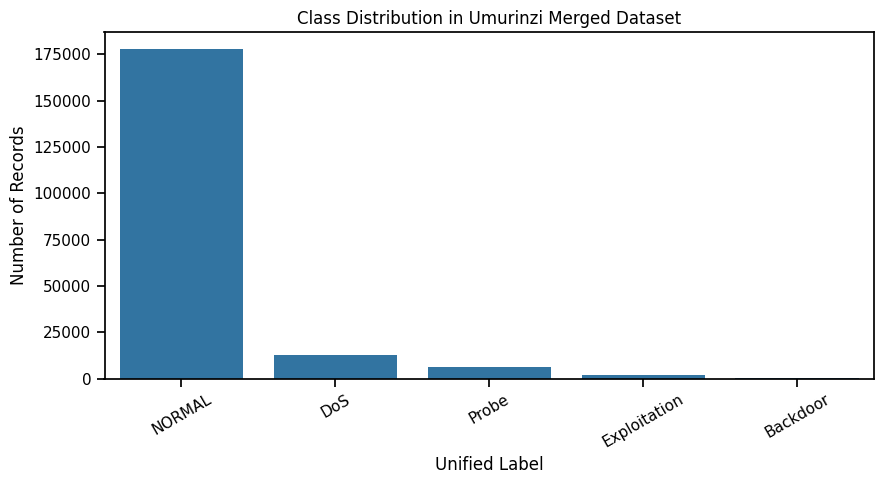

In [9]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='unified_label', order=df['unified_label'].value_counts().index)
plt.title('Class Distribution in Umurinzi Merged Dataset')
plt.xlabel('Unified Label')
plt.ylabel('Number of Records')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,count
dataset_source,
CICIDS2017,99996
UNSW-NB15,99758


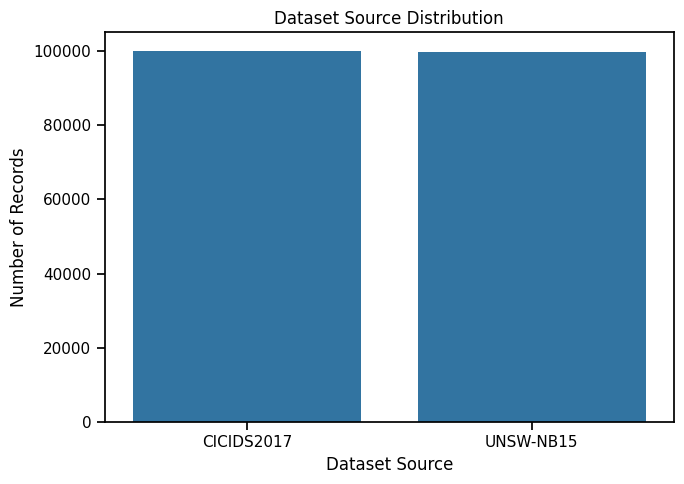

In [10]:
source_map = {0: 'CICIDS2017', 1: 'UNSW-NB15'}
source_counts = df['dataset_source'].map(source_map).value_counts()

display(source_counts.to_frame('count'))

plt.figure(figsize=(7, 5))
sns.barplot(x=source_counts.index, y=source_counts.values)
plt.title('Dataset Source Distribution')
plt.xlabel('Dataset Source')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [11]:
print('Numeric summary statistics:')
numeric_feature_cols = [c for c in df.columns if c not in ['unified_label']]
display(df[numeric_feature_cols].describe().T)

Numeric summary statistics:


,count,mean,std,min,25%,50%,75%,max
dest_port,199754.0,1.113157e+04,1.941379e+04,0.0,53.000000,111.000000,9968.000000,6.553200e+04
protocol,199754.0,4.549826e+00,5.782037e+00,0.0,0.000000,0.000000,6.000000,1.700000e+01
flow_duration,199754.0,8.581986e+06,2.617701e+07,-1.0,1086.000000,34842.500000,769912.250000,1.200000e+08
fwd_pkts,199754.0,2.255190e+01,7.459552e+01,0.0,2.000000,4.000000,21.000000,1.869100e+04
bwd_pkts,199754.0,2.819335e+01,1.181289e+02,0.0,2.000000,4.000000,18.000000,2.671000e+04
fwd_bytes,199754.0,2.729150e+03,2.893872e+04,0.0,66.000000,350.000000,2230.000000,7.132312e+06
bwd_bytes,199754.0,2.461112e+04,1.894268e+05,0.0,122.000000,320.000000,10168.000000,5.140000e+07
fwd_pkt_len_mean,199754.0,9.646532e+01,1.835983e+02,0.0,36.000000,59.387500,86.000000,3.893333e+03
bwd_pkt_len_mean,199754.0,3.338082e+02,5.063735e+02,0.0,59.000000,98.000000,534.000000,3.927262e+03
fwd_iat_mean,199754.0,1.453307e+06,7.200525e+06,0.0,0.276813,3.000000,107.263531,1.200000e+08


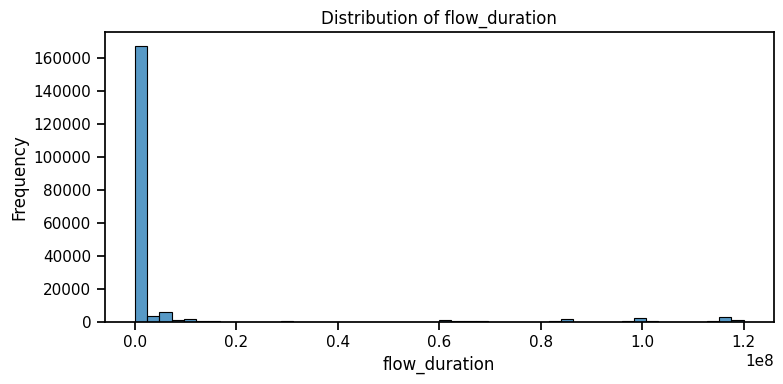

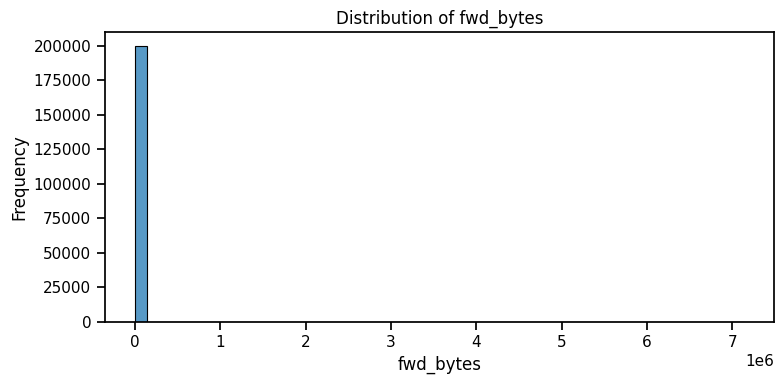

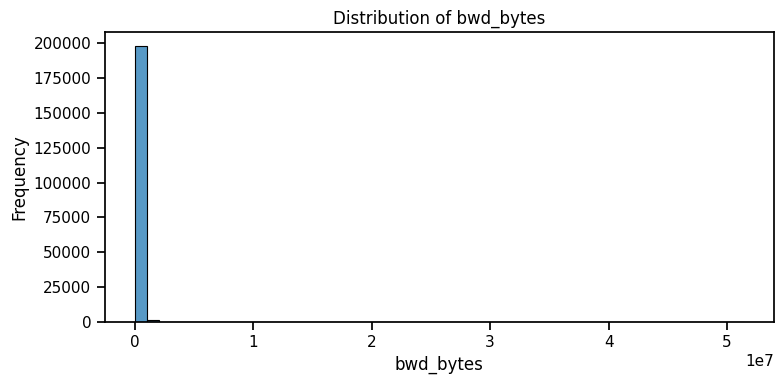

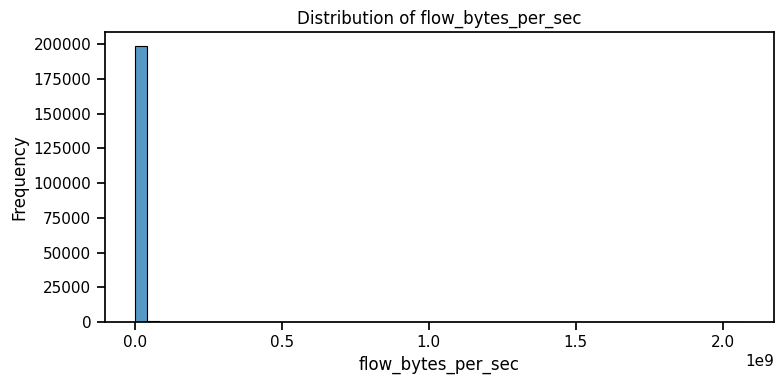

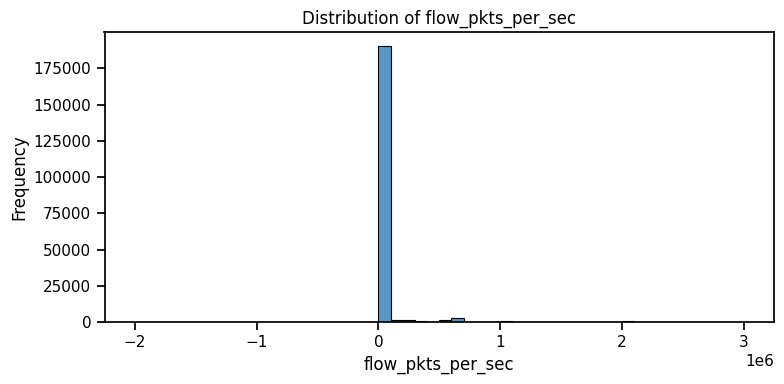

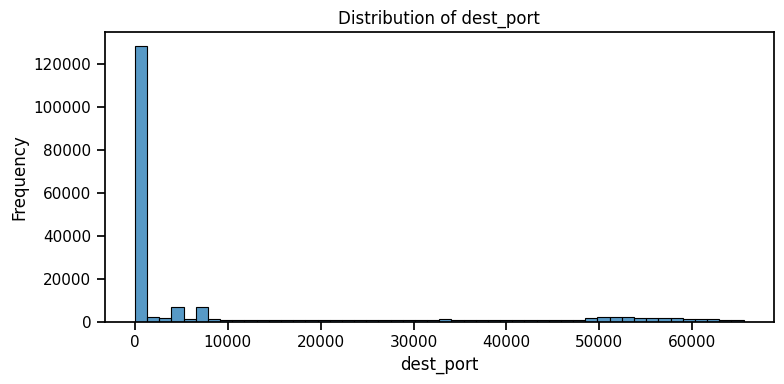

In [12]:
important_features = [
    'flow_duration', 'fwd_bytes', 'bwd_bytes',
    'flow_bytes_per_sec', 'flow_pkts_per_sec', 'dest_port'
]

for col in important_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, kde=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

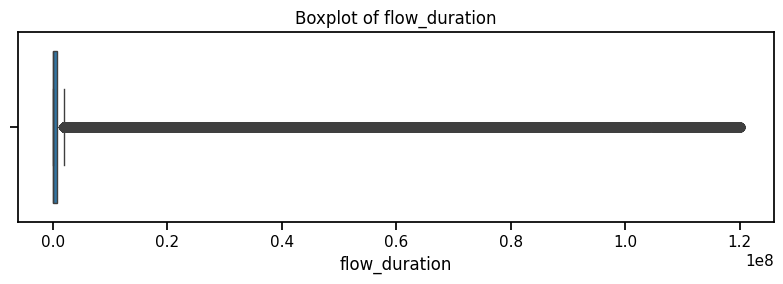

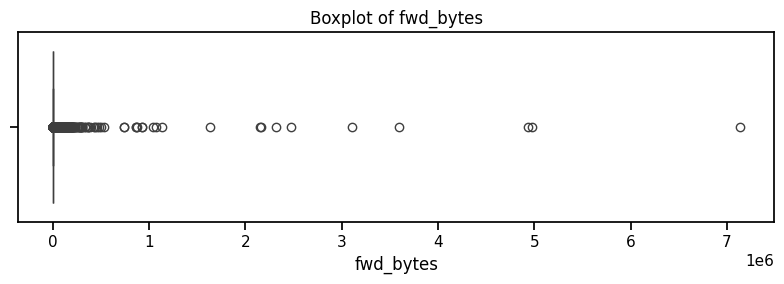

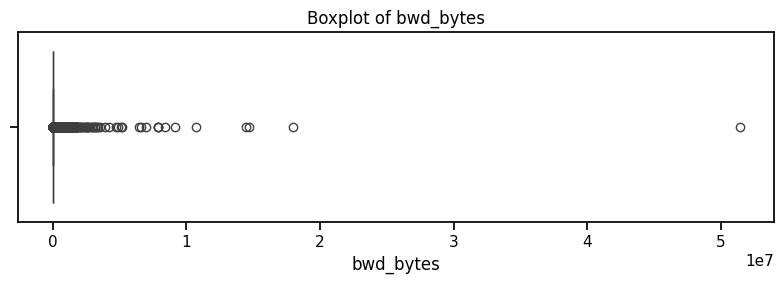

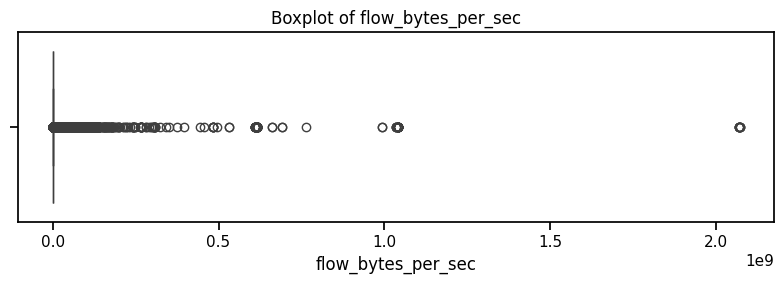

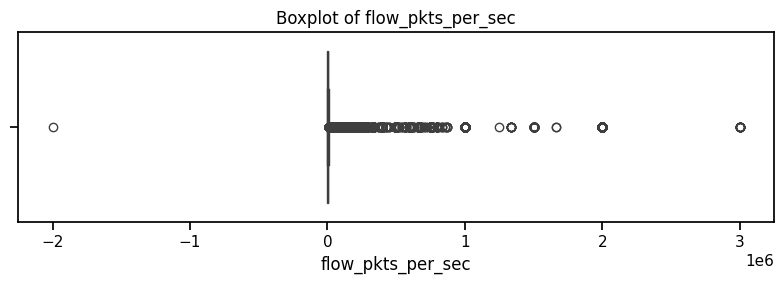

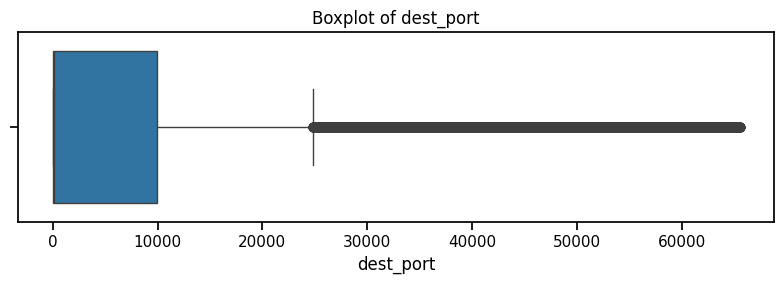

In [13]:
for col in important_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col].replace([np.inf, -np.inf], np.nan))
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

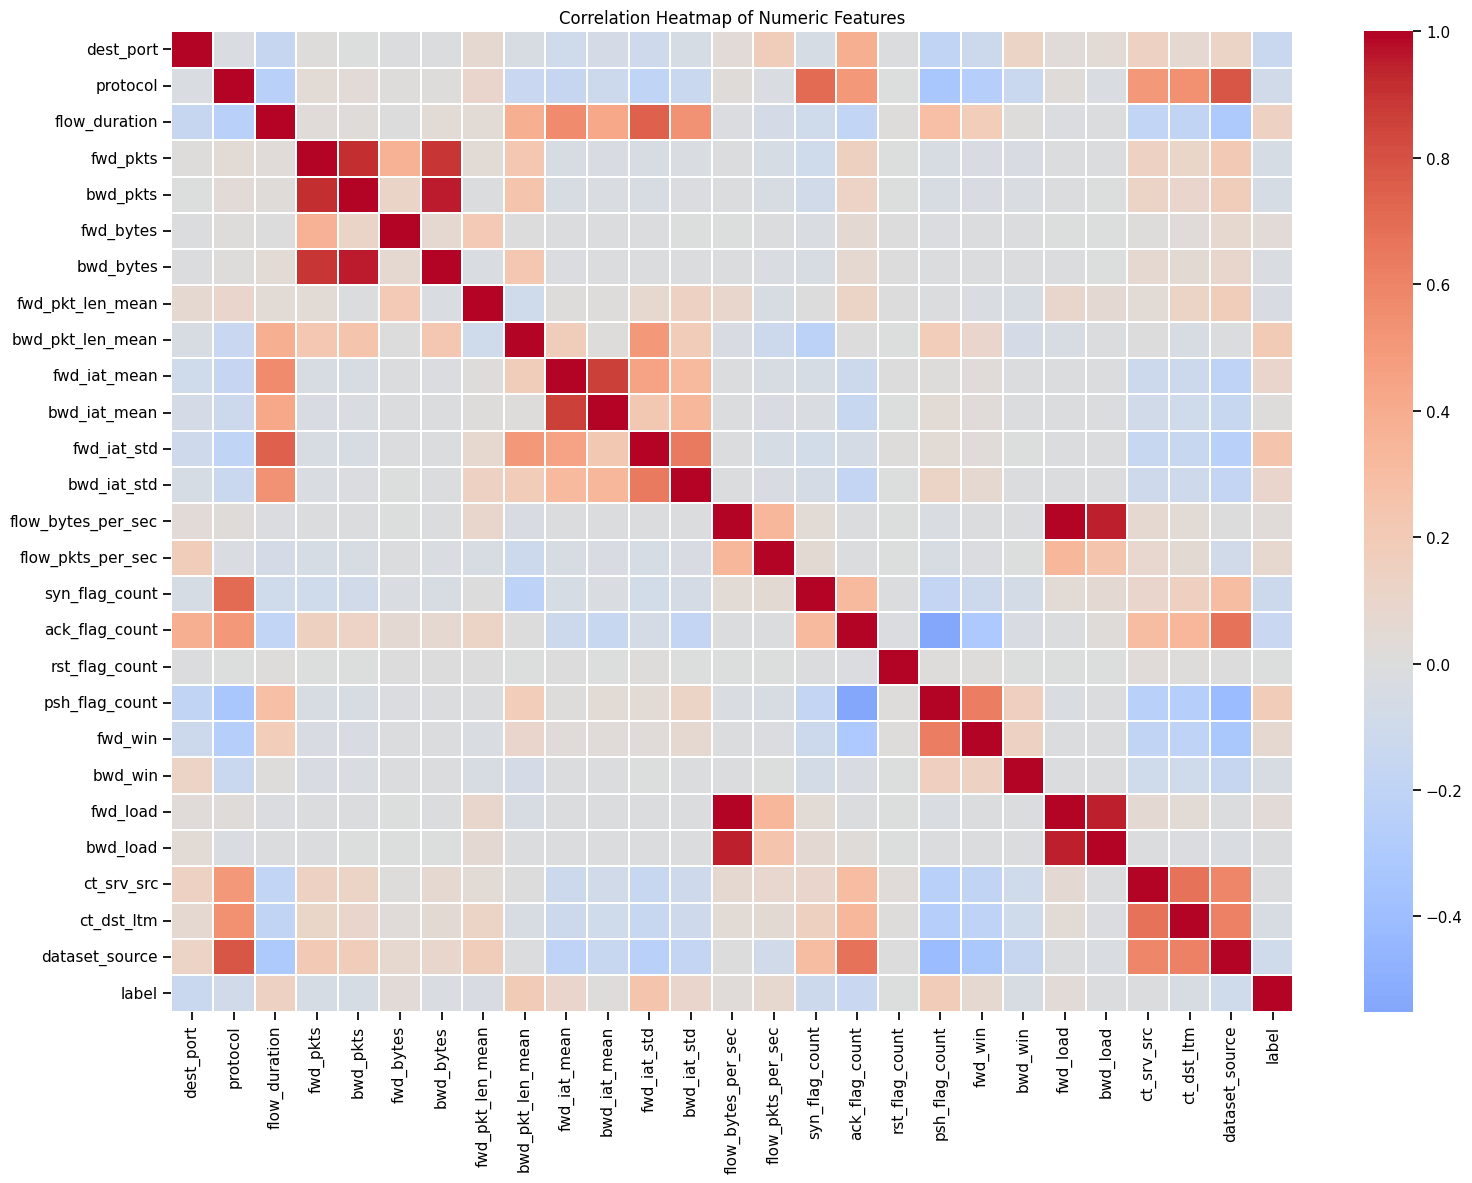

In [14]:
plt.figure(figsize=(16, 12))
corr = df.drop(columns=['unified_label']).corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## 6. Data Quality Verification

This section checks for missing values, duplicates, infinities, and invalid labels.

Missing values per column:


,missing_count


Total missing values: 0


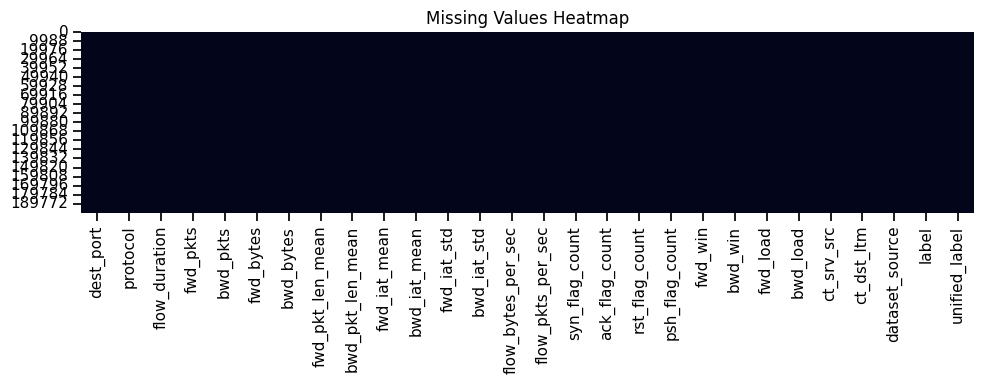

In [15]:
print('Missing values per column:')
missing = df.isna().sum()
display(missing[missing > 0].to_frame('missing_count'))
print('Total missing values:', int(missing.sum()))

plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [16]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count:,}')

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f'Infinite numeric values: {inf_count:,}')

valid_labels = {0, 1, 2, 3, 4}
invalid_label_count = (~df['label'].isin(valid_labels)).sum()
print(f'Invalid numeric labels: {invalid_label_count:,}')

Duplicate rows: 1,365
Infinite numeric values: 0
Invalid numeric labels: 0


In [17]:
# Clean any remaining data-quality issues defensively.
rows_before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print(f'Rows before cleaning: {rows_before:,}')
print(f'Rows after cleaning : {rows_after:,}')
print(f'Rows removed        : {rows_before - rows_after:,}')

Rows before cleaning: 199,754
Rows after cleaning : 198,389
Rows removed        : 1,365


## 7. Feature Engineering

The proposal mentions packet rates, inter-arrival features, and byte ratios. The merged dataset already contains core engineered traffic-rate and IAT features. This section adds safe ratio features that may improve model performance.

In [18]:
# Add ratio features using small epsilon to prevent division by zero.
eps = 1e-9

df['byte_ratio_fwd_bwd'] = df['fwd_bytes'] / (df['bwd_bytes'] + eps)
df['pkt_ratio_fwd_bwd'] = df['fwd_pkts'] / (df['bwd_pkts'] + eps)
df['avg_bytes_per_pkt'] = (df['fwd_bytes'] + df['bwd_bytes']) / (df['fwd_pkts'] + df['bwd_pkts'] + eps)
df['iat_mean_ratio'] = df['fwd_iat_mean'] / (df['bwd_iat_mean'] + eps)
df['load_ratio_fwd_bwd'] = df['fwd_load'] / (df['bwd_load'] + eps)

# Replace any generated infinities.
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

engineered_features = [
    'byte_ratio_fwd_bwd',
    'pkt_ratio_fwd_bwd',
    'avg_bytes_per_pkt',
    'iat_mean_ratio',
    'load_ratio_fwd_bwd'
]

print('Engineered features added:')
for f in engineered_features:
    print('-', f)

print('Updated shape:', df.shape)

Engineered features added:
- byte_ratio_fwd_bwd
- pkt_ratio_fwd_bwd
- avg_bytes_per_pkt
- iat_mean_ratio
- load_ratio_fwd_bwd
Updated shape: (198389, 33)


## 8. Define Features and Target

`label` is the numeric target used for training.  
`unified_label` is kept only for interpretation and reporting.  
`dataset_source` is retained as a feature because the merged dataset uses two sources and the source can help capture dataset-specific characteristics. A later ablation experiment can remove it if required.

In [19]:
label_mapping = {
    0: 'NORMAL',
    1: 'DoS',
    2: 'Probe',
    3: 'Exploitation',
    4: 'Backdoor'
}

feature_cols = [c for c in df.columns if c not in ['label', 'unified_label']]
target_col = 'label'

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

print(f'Number of input features: {X.shape[1]}')
print('Input features:')
for f in feature_cols:
    print('-', f)

print('\nTarget distribution:')
display(y.value_counts().sort_index().rename(index=label_mapping).to_frame('count'))

Number of input features: 31
Input features:
- dest_port
- protocol
- flow_duration
- fwd_pkts
- bwd_pkts
- fwd_bytes
- bwd_bytes
- fwd_pkt_len_mean
- bwd_pkt_len_mean
- fwd_iat_mean
- bwd_iat_mean
- fwd_iat_std
- bwd_iat_std
- flow_bytes_per_sec
- flow_pkts_per_sec
- syn_flag_count
- ack_flag_count
- rst_flag_count
- psh_flag_count
- fwd_win
- bwd_win
- fwd_load
- bwd_load
- ct_srv_src
- ct_dst_ltm
- dataset_source
- byte_ratio_fwd_bwd
- pkt_ratio_fwd_bwd
- avg_bytes_per_pkt
- iat_mean_ratio
- load_ratio_fwd_bwd

Target distribution:


,count
label,
NORMAL,177105
DoS,13019
Probe,6251
Exploitation,1843
Backdoor,171


## 9. Information Gain Feature Selection

The proposal requires feature selection using Information Gain. In scikit-learn, this is implemented using mutual information.

Important: feature selection is computed on the training data only after splitting to reduce leakage risk.

## 10. Stratified Train/Test Split

The proposal requires an 80/20 split stratified by the target class.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')

train_dist = y_train.value_counts().sort_index().rename(index=label_mapping)
test_dist = y_test.value_counts().sort_index().rename(index=label_mapping)

display(pd.DataFrame({'train_count': train_dist, 'test_count': test_dist}))

X_train: (158711, 31)
X_test : (39678, 31)
y_train: (158711,)
y_test : (39678,)


,train_count,test_count
label,,
NORMAL,141684,35421
DoS,10415,2604
Probe,5001,1250
Exploitation,1474,369
Backdoor,137,34


## 11. Min-Max Scaling

The proposal specifies Min-Max normalization. The scaler is fitted on the training data only and then applied to both training and test data.

In [21]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Scaling complete.')
display(X_train_scaled.describe().T[['min', 'max']].head())

Scaling complete.


,min,max
dest_port,0.0,1.0
protocol,0.0,1.0
flow_duration,0.0,1.0
fwd_pkts,0.0,1.0
bwd_pkts,0.0,1.0


Information Gain computed in 7.47 seconds


,feature,information_gain
0,bwd_bytes,0.274229
1,fwd_bytes,0.268518
2,avg_bytes_per_pkt,0.261913
3,bwd_pkt_len_mean,0.260001
4,fwd_iat_mean,0.213411
5,fwd_pkt_len_mean,0.208966
6,bwd_win,0.208400
7,dest_port,0.205749
8,flow_bytes_per_sec,0.203997
9,fwd_load,0.198300


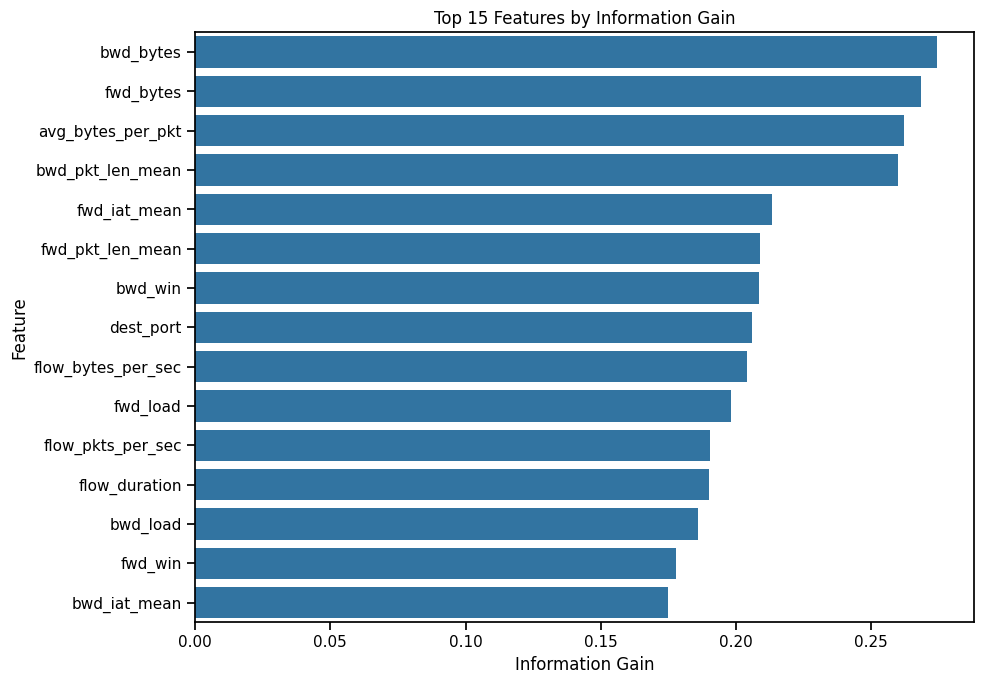

In [22]:
mi_start = time.time()
mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=RANDOM_STATE,
    discrete_features=False
)
mi_time = time.time() - mi_start

mi_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'information_gain': mi_scores
}).sort_values('information_gain', ascending=False).reset_index(drop=True)

print(f'Information Gain computed in {mi_time:.2f} seconds')
display(mi_df)

plt.figure(figsize=(10, 7))
sns.barplot(data=mi_df.head(15), y='feature', x='information_gain')
plt.title('Top 15 Features by Information Gain')
plt.xlabel('Information Gain')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [23]:
if TOP_K_FEATURES is not None:
    selected_features = mi_df.head(TOP_K_FEATURES)['feature'].tolist()
else:
    selected_features = mi_df['feature'].tolist()

X_train_selected = X_train_scaled[selected_features].copy()
X_test_selected = X_test_scaled[selected_features].copy()

print(f'Selected features: {len(selected_features)}')
for f in selected_features:
    print('-', f)

Selected features: 31
- bwd_bytes
- fwd_bytes
- avg_bytes_per_pkt
- bwd_pkt_len_mean
- fwd_iat_mean
- fwd_pkt_len_mean
- bwd_win
- dest_port
- flow_bytes_per_sec
- fwd_load
- flow_pkts_per_sec
- flow_duration
- bwd_load
- fwd_win
- bwd_iat_mean
- fwd_iat_std
- bwd_pkts
- fwd_pkts
- bwd_iat_std
- dataset_source
- ct_dst_ltm
- byte_ratio_fwd_bwd
- ct_srv_src
- protocol
- iat_mean_ratio
- ack_flag_count
- pkt_ratio_fwd_bwd
- load_ratio_fwd_bwd
- psh_flag_count
- syn_flag_count
- rst_flag_count


## 12. SMOTE Class Balancing

The proposal requires SMOTE to handle class imbalance. SMOTE is applied **only to the training set** after splitting and scaling. The test set remains untouched to represent real evaluation conditions.

Class distribution before SMOTE:


,before_smote
label,
NORMAL,141684
DoS,10415
Probe,5001
Exploitation,1474
Backdoor,137



Class distribution after SMOTE:


,after_smote
label,
NORMAL,141684
DoS,141684
Probe,141684
Exploitation,141684
Backdoor,141684


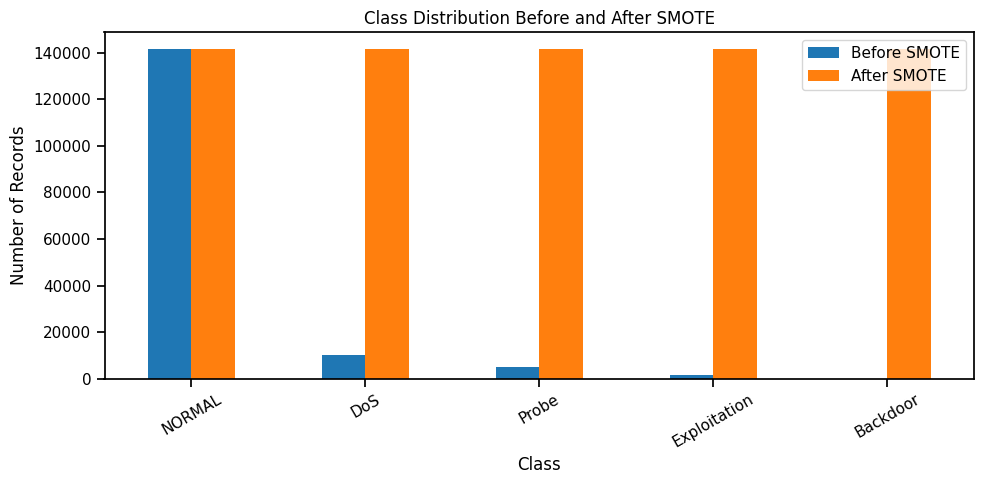

In [24]:
print('Class distribution before SMOTE:')
before_smote = y_train.value_counts().sort_index().rename(index=label_mapping)
display(before_smote.to_frame('before_smote'))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

print('\nClass distribution after SMOTE:')
after_smote = pd.Series(y_train_balanced).value_counts().sort_index().rename(index=label_mapping)
display(after_smote.to_frame('after_smote'))

comparison_smote = pd.DataFrame({
    'Before SMOTE': before_smote,
    'After SMOTE': after_smote
})

comparison_smote.plot(kind='bar', figsize=(10, 5))
plt.title('Class Distribution Before and After SMOTE')
plt.xlabel('Class')
plt.ylabel('Number of Records')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 13. Evaluation Utility Functions

The proposal requires accuracy, precision, recall, F1-score, per-class metrics, confusion matrices, and false positive rate.

In [25]:
def calculate_false_positive_rate(y_true, y_pred, labels=None):
    # Return macro-average false positive rate for multiclass classification.
    if labels is None:
        labels = sorted(np.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fprs = []
    total = cm.sum()
    for i, label in enumerate(labels):
        fp = cm[:, i].sum() - cm[i, i]
        tn = total - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        denom = fp + tn
        fpr = fp / denom if denom > 0 else 0
        fprs.append(fpr)
    return float(np.mean(fprs)), dict(zip(labels, fprs))


def evaluate_model(model_name, model, X_eval, y_eval):
    # Evaluate model and return metric dictionary.
    pred_start = time.time()
    y_pred = model.predict(X_eval)
    pred_time = time.time() - pred_start

    accuracy = accuracy_score(y_eval, y_pred)
    precision = precision_score(y_eval, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_eval, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_eval, y_pred, average='macro', zero_division=0)
    fpr_macro, fpr_per_class = calculate_false_positive_rate(y_eval, y_pred, labels=list(label_mapping.keys()))

    print(f'\n===== {model_name} Evaluation =====')
    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'FPR      : {fpr_macro:.4f}')
    print(f'Prediction time: {pred_time:.2f} seconds')

    print('\nClassification Report:')
    print(classification_report(
        y_eval,
        y_pred,
        target_names=[label_mapping[i] for i in sorted(label_mapping)],
        zero_division=0
    ))

    cm = confusion_matrix(y_eval, y_pred, labels=list(label_mapping.keys()))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[label_mapping[i] for i in sorted(label_mapping)]
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=30)
    plt.title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
        'false_positive_rate_macro': fpr_macro,
        'prediction_time_seconds': pred_time,
        'fpr_per_class': fpr_per_class,
        'y_pred': y_pred
    }

results = []
trained_models = {}
training_times = {}

## 14. Model 1: Logistic Regression Baseline

Logistic Regression is included as a simple baseline model, as stated in the proposal.

Logistic Regression training time: 14.38 seconds

===== Logistic Regression Evaluation =====
Accuracy : 0.7148
Precision: 0.3950
Recall   : 0.7663
F1-score : 0.4236
FPR      : 0.0646
Prediction time: 0.00 seconds

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.70      0.82     35421
         DoS       0.61      0.93      0.74      2604
       Probe       0.31      0.79      0.44      1250
Exploitation       0.06      0.83      0.10       369
    Backdoor       0.01      0.59      0.02        34

    accuracy                           0.71     39678
   macro avg       0.39      0.77      0.42     39678
weighted avg       0.94      0.71      0.79     39678



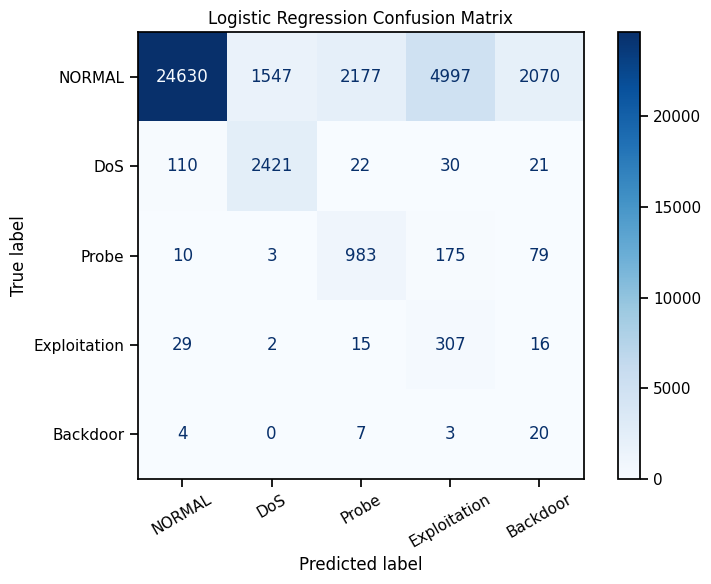

In [26]:
lr = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='saga',
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE
)

lr_start = time.time()
lr.fit(X_train_balanced, y_train_balanced)
lr_train_time = time.time() - lr_start

trained_models['Logistic Regression'] = lr
training_times['Logistic Regression'] = lr_train_time

print(f'Logistic Regression training time: {lr_train_time:.2f} seconds')
lr_result = evaluate_model('Logistic Regression', lr, X_test_selected, y_test)
lr_result['training_time_seconds'] = lr_train_time
results.append(lr_result)

## 15. Model 2: Random Forest with 5-Fold Stratified Cross-Validation and Grid Search

Random Forest is a strong tree-based model for tabular IDS data and supports SHAP TreeExplainer.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 8.9min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 9.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 9.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 9.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 9.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=13.5min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=13.6min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=13.6min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=13.7min
[CV] END ma

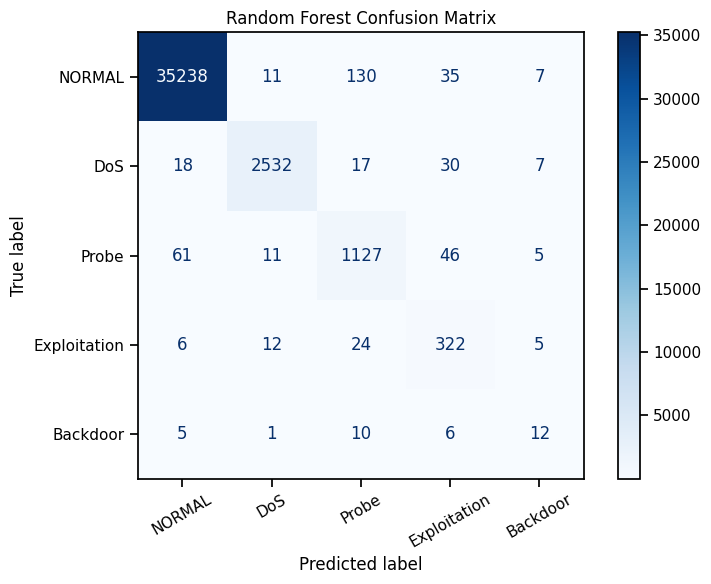

In [27]:
rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    class_weight=None
)

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20, 40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=N_JOBS,
    verbose=2
)

rf_start = time.time()
rf_grid.fit(X_train_balanced, y_train_balanced)
rf_train_time = time.time() - rf_start

best_rf = rf_grid.best_estimator_
trained_models['Random Forest'] = best_rf
training_times['Random Forest'] = rf_train_time

print('Best Random Forest parameters:')
print(rf_grid.best_params_)
print(f'Best CV F1-macro: {rf_grid.best_score_:.4f}')
print(f'Random Forest training time: {rf_train_time:.2f} seconds')

rf_result = evaluate_model('Random Forest', best_rf, X_test_selected, y_test)
rf_result['training_time_seconds'] = rf_train_time
rf_result['best_cv_f1_macro'] = rf_grid.best_score_
results.append(rf_result)

## 16. Model 3: XGBoost with 5-Fold Stratified Cross-Validation and Grid Search

XGBoost is included because it is highly effective on structured tabular data and is commonly used in IDS studies.

In [ ]:
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_mapping),
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=N_JOBS,
    verbose=2
)

xgb_start = time.time()
xgb_grid.fit(X_train_balanced, y_train_balanced)
xgb_train_time = time.time() - xgb_start

best_xgb = xgb_grid.best_estimator_
trained_models['XGBoost'] = best_xgb
training_times['XGBoost'] = xgb_train_time

print('Best XGBoost parameters:')
print(xgb_grid.best_params_)
print(f'Best CV F1-macro: {xgb_grid.best_score_:.4f}')
print(f'XGBoost training time: {xgb_train_time:.2f} seconds')

xgb_result = evaluate_model('XGBoost', best_xgb, X_test_selected, y_test)
xgb_result['training_time_seconds'] = xgb_train_time
xgb_result['best_cv_f1_macro'] = xgb_grid.best_score_
results.append(xgb_result)

## 17. Model Comparison

The proposal requires comparing Logistic Regression, Random Forest, and XGBoost using accuracy, precision, recall, F1-score, and false positive rate.

In [ ]:
comparison_rows = []
for r in results:
    comparison_rows.append({
        'Model': r['model'],
        'Accuracy': r['accuracy'],
        'Precision Macro': r['precision_macro'],
        'Recall Macro': r['recall_macro'],
        'F1 Macro': r['f1_macro'],
        'False Positive Rate': r['false_positive_rate_macro'],
        'Training Time (s)': r.get('training_time_seconds', np.nan),
        'Prediction Time (s)': r['prediction_time_seconds']
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=['F1 Macro', 'Recall Macro', 'Accuracy'],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

comparison_df.to_csv(OUTPUT_DIR / 'model_comparison_results.csv', index=False)

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro', 'False Positive Rate']

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=comparison_df, x='Model', y=metric)
    plt.title(f'Model Comparison: {metric}')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 18. Best Model Selection

The best model is selected using this IDS-focused priority:

1. Highest macro F1-score  
2. Highest macro recall  
3. Highest accuracy  
4. Lowest false positive rate  

Macro F1 and recall are prioritized because intrusion detection must perform well across all attack classes, not only the majority class.

In [ ]:
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f'Best model selected: {best_model_name}')
display(comparison_df.iloc[[0]])

## 19. Per-Class Metrics for the Best Model

This section gives detailed per-class performance for the selected model.

In [ ]:
best_y_pred = best_model.predict(X_test_selected)
report_dict = classification_report(
    y_test,
    best_y_pred,
    target_names=[label_mapping[i] for i in sorted(label_mapping)],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
display(report_df)
report_df.to_csv(OUTPUT_DIR / 'best_model_classification_report.csv')

## 20. SHAP Explainability

The proposal requires SHAP explainability. This section generates global and local explanations for the selected tree-based model.

If Logistic Regression wins, SHAP will use XGBoost or Random Forest as the explainable tree model, because SHAP TreeExplainer is designed for tree-based models.

In [ ]:
# Select tree model for SHAP.
if best_model_name in ['Random Forest', 'XGBoost']:
    shap_model_name = best_model_name
    shap_model = best_model
elif 'XGBoost' in trained_models:
    shap_model_name = 'XGBoost'
    shap_model = trained_models['XGBoost']
else:
    shap_model_name = 'Random Forest'
    shap_model = trained_models['Random Forest']

print(f'SHAP explainability model: {shap_model_name}')

# Use a sample for SHAP to avoid excessive memory usage.
SHAP_SAMPLE_SIZE = min(2000, len(X_test_selected))
X_shap = X_test_selected.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

print('SHAP values computed.')

In [ ]:
# Global SHAP summary.
# SHAP output format differs by model/library version, so handle both cases.
try:
    shap.summary_plot(shap_values, X_shap, feature_names=selected_features, show=True)
except Exception as e:
    print('Could not create standard multiclass SHAP summary plot:', e)
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], X_shap, feature_names=selected_features, show=True)

In [ ]:
# SHAP bar plot for global feature importance.
try:
    shap.summary_plot(shap_values, X_shap, feature_names=selected_features, plot_type='bar', show=True)
except Exception as e:
    print('Could not create standard SHAP bar plot:', e)
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], X_shap, feature_names=selected_features, plot_type='bar', show=True)

In [ ]:
# Local explanations using waterfall plots for a few examples.
# This cell is version-tolerant. If waterfall fails, it prints the prediction details.
X_local = X_shap.head(5)
local_preds = shap_model.predict(X_local)

print('Local explanation samples:')
for i, pred in enumerate(local_preds):
    print(f'Sample {i}: predicted class = {pred} ({label_mapping[int(pred)]})')

try:
    explanation = explainer(X_local)
    for i in range(min(3, len(X_local))):
        print(f'\nWaterfall plot for sample {i}')
        # For multiclass models, select the predicted class output if needed.
        pred_class = int(local_preds[i])
        if len(explanation.values.shape) == 3:
            shap.plots.waterfall(explanation[i, :, pred_class], max_display=12)
        else:
            shap.plots.waterfall(explanation[i], max_display=12)
except Exception as e:
    print('Waterfall plots could not be generated in this SHAP version:', e)

## 21. Isolation Forest Anomaly Detection

The proposal includes Isolation Forest as an anomaly detection module to support unknown or zero-day-like traffic detection. It is not used to classify known attack categories; instead, it flags unusual records for analyst review.

In [ ]:
# Train Isolation Forest on scaled training data.
# This uses selected features and original imbalanced training distribution.
iso = IsolationForest(
    n_estimators=300,
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

iso_start = time.time()
iso.fit(X_train_selected)
iso_train_time = time.time() - iso_start

iso_scores = iso.decision_function(X_test_selected)
iso_pred = iso.predict(X_test_selected)  # 1 = normal, -1 = anomaly

anomaly_count = int((iso_pred == -1).sum())
normal_count = int((iso_pred == 1).sum())

print(f'Isolation Forest training time: {iso_train_time:.2f} seconds')
print(f'Normal records flagged by Isolation Forest : {normal_count:,}')
print(f'Anomaly records flagged by Isolation Forest: {anomaly_count:,}')
print(f'Anomaly percentage: {(anomaly_count / len(iso_pred)) * 100:.2f}%')

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(iso_scores, bins=50, kde=True)
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

iso_summary = pd.DataFrame({
    'true_label': y_test.values,
    'true_label_name': y_test.map(label_mapping).values,
    'isolation_score': iso_scores,
    'isolation_prediction': iso_pred,
    'is_anomaly': iso_pred == -1
})

print('Anomaly flags by true class:')
display(pd.crosstab(iso_summary['true_label_name'], iso_summary['is_anomaly']))

iso_summary.to_csv(OUTPUT_DIR / 'isolation_forest_test_scores.csv', index=False)

## 22. Save Final Artifacts

The proposal states that the trained model will later be used by a FastAPI backend and React dashboard. This section saves the necessary deployment artifacts.

In [ ]:
joblib.dump(best_model, OUTPUT_DIR / 'best_intrusion_detection_model.joblib')
joblib.dump(scaler, OUTPUT_DIR / 'minmax_scaler.joblib')
joblib.dump(iso, OUTPUT_DIR / 'isolation_forest_model.joblib')

with open(OUTPUT_DIR / 'selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=4)

with open(OUTPUT_DIR / 'label_mapping.json', 'w') as f:
    json.dump({str(k): v for k, v in label_mapping.items()}, f, indent=4)

with open(OUTPUT_DIR / 'best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print('Saved artifacts:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print('-', path.name)

## 23. Final Results Summary

This section summarizes the final experimental results for the report and presentation.

In [ ]:
final_summary = {
    'Dataset': 'umurinzi_merged_800k.csv',
    'Final Rows Used': len(df),
    'Input Features Used': len(selected_features),
    'Classes': len(label_mapping),
    'Train/Test Split': '80/20 stratified',
    'Scaling': 'MinMaxScaler',
    'Class Balancing': 'SMOTE on training set only',
    'Feature Selection': 'Information Gain / mutual_info_classif',
    'Models Compared': 'Logistic Regression, Random Forest, XGBoost',
    'Best Model': best_model_name,
    'Best Accuracy': comparison_df.iloc[0]['Accuracy'],
    'Best Precision Macro': comparison_df.iloc[0]['Precision Macro'],
    'Best Recall Macro': comparison_df.iloc[0]['Recall Macro'],
    'Best F1 Macro': comparison_df.iloc[0]['F1 Macro'],
    'Best False Positive Rate': comparison_df.iloc[0]['False Positive Rate'],
    'Explainability': f'SHAP TreeExplainer using {shap_model_name}',
    'Anomaly Detection': 'Isolation Forest'
}

final_summary_df = pd.DataFrame(final_summary.items(), columns=['Item', 'Result'])
display(final_summary_df)
final_summary_df.to_csv(OUTPUT_DIR / 'final_results_summary.csv', index=False)

## 24. Academic Notes for Defense

Important points to explain during presentation:

1. The raw CICIDS2017 and UNSW-NB15 datasets were already cleaned, aligned, and merged into `umurinzi_merged_800k.csv`.
2. The dataset contains 400,000 records from CICIDS2017 and 400,000 records from UNSW-NB15.
3. The target is five-class intrusion detection: NORMAL, DoS, Probe, Exploitation, and Backdoor.
4. SMOTE was applied only on the training set to prevent test-data leakage.
5. Min-Max scaling was fitted only on training data.
6. Information Gain feature ranking was computed using training data only.
7. Logistic Regression was used as the baseline model.
8. Random Forest and XGBoost were tuned using 5-fold stratified cross-validation.
9. The best model was selected mainly using macro F1-score and macro recall, because intrusion detection must perform well across all classes.
10. SHAP was used to explain model decisions globally and locally.
11. Isolation Forest was added to support anomaly detection for unknown or zero-day-like behavior.
12. Saved artifacts can be used later by FastAPI and React dashboard components.